## EXTRACION DE DATOS

### Contexto y origen de los datos
- Problema: clasificar radiografías de tórax en dos clases (NORMAL vs PNEUMONIA) para apoyar el diagnóstico de neumonía.
- Origen de datos: dataset **Chest X-Ray Images (Pneumonia)** publicado por Paul Mooney en Kaggle: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
- Notas: conjunto de imágenes frontal de tórax etiquetadas por especialistas; se usa únicamente para fines académicos en este proyecto.


In [23]:
# import kagglehub

# # Download latest version
# base_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

# print("Path to dataset files:", base_path)

In [24]:
# Use a raw string to avoid interpreting backslashes as escape sequences
base_path = r"C:\Users\SPARTAN PC\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray"

## ESTRUCTURA DE LOS DIRECTORIOS

In [25]:
import os
for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files[:3]:  # Mostrar solo los primeros 3 archivos
        print(f'{subindent}{file}')
    if len(files) > 3:
        print(f'{subindent}... y {len(files) - 3} archivos más')


chest_xray/
  modelo_v2_mejor.keras
  test_15/
    NORMAL/
      IM-0006-0001.jpeg
      IM-0007-0001.jpeg
      IM-0022-0001.jpeg
      ... y 235 archivos más
    PNEUMONIA/
      person1005_virus_1688.jpeg
      person1007_virus_1690.jpeg
      person1008_bacteria_2939.jpeg
      ... y 639 archivos más
  test_new/
    NORMAL/
      IM-0001-0001.jpeg
      IM-0003-0001.jpeg
      IM-0005-0001.jpeg
      ... y 190 archivos más
    PNEUMONIA/
      person100_bacteria_475.jpeg
      person100_bacteria_477.jpeg
      person100_bacteria_478.jpeg
      ... y 315 archivos más
  test_val/
    NORMAL/
      IM-0001-0001.jpeg
      IM-0003-0001.jpeg
      IM-0005-0001.jpeg
      ... y 239 archivos más
    PNEUMONIA/
      person100_bacteria_475.jpeg
      person100_bacteria_477.jpeg
      person100_bacteria_478.jpeg
      ... y 395 archivos más
  train/
    NORMAL/
      IM-0115-0001.jpeg
      IM-0117-0001.jpeg
      IM-0119-0001.jpeg
      ... y 1338 archivos más
    PNEUMONIA/
      person10

In [26]:
# La ruta base ya apunta a 'chest_xray', evitamos agregar un nivel extra
path = base_path


### Revisión de distribución y preparación del split 70/15/15


In [27]:
import os

source_splits = [name for name in ['train', 'test', 'val', 'test_val']
                 if os.path.isdir(os.path.join(path, name))]
split_paths = {name: os.path.join(path, name) for name in source_splits}

class_counts = {name: {} for name in source_splits}

for split_name, split_path in split_paths.items():
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            class_counts[split_name][class_name] = count

total_counts = {}
for class_name in set().union(*class_counts.values()):
    total_counts[class_name] = sum(class_counts[split].get(class_name, 0) for split in class_counts)

print("\n" + "=" * 50)
print('DISTRIBUCIÓN ORIGINAL POR SPLIT')
print("=" * 50)
for split, classes in class_counts.items():
    print(f"\n{split.upper()}:")
    for class_name, count in classes.items():
        print(f"  {class_name}: {count} imágenes")

print("\nTOTAL UNIFICADO:")
for class_name, count in total_counts.items():
    print(f"  {class_name}: {count} imágenes en total")



DISTRIBUCIÓN ORIGINAL POR SPLIT

TRAIN:
  NORMAL: 1341 imágenes
  PNEUMONIA: 3875 imágenes

TEST_VAL:
  NORMAL: 242 imágenes
  PNEUMONIA: 398 imágenes

TOTAL UNIFICADO:
  PNEUMONIA: 4273 imágenes en total
  NORMAL: 1583 imágenes en total


In [28]:
import os
import shutil
import random

target_train_path = os.path.join(path, 'train_70')
target_val_path = os.path.join(path, 'val_15')
target_test_path = os.path.join(path, 'test_15')
targets = [target_train_path, target_val_path, target_test_path]

# Limpiamos particiones previas para evitar duplicados
for split in targets:
    if os.path.exists(split):
        shutil.rmtree(split)
    for class_name in ['PNEUMONIA', 'NORMAL']:
        os.makedirs(os.path.join(split, class_name), exist_ok=True)

random.seed(1337)  # Reproducibilidad


## División 70/15/15 combinando todo el dataset

Se unifican todas las carpetas disponibles del dataset original (`train`, `test`, `val` y/o `test_val`). Tras mezclar por clase, se generan tres splits estratificados: **70%** entrenamiento, **15%** validación y **15%** prueba. Se usa la semilla 1337 para que la partición sea reproducible.


In [29]:
if not split_paths:
    raise ValueError('No se encontraron carpetas de origen (train/test/val/test_val) para combinar.')

for class_name in ['NORMAL', 'PNEUMONIA']:
    all_files = []

    for split_name, split_path in split_paths.items():
        class_dir = os.path.join(split_path, class_name)
        if os.path.isdir(class_dir):
            all_files.extend([
                os.path.join(class_dir, f)
                for f in os.listdir(class_dir)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])

    if not all_files:
        print(f'No se encontraron imágenes para {class_name}. Revisa las rutas.')
        continue

    random.shuffle(all_files)

    total = len(all_files)
    train_cut = int(0.70 * total)
    val_cut = train_cut + int(0.15 * total)

    splits = {
        target_train_path: all_files[:train_cut],
        target_val_path: all_files[train_cut:val_cut],
        target_test_path: all_files[val_cut:],
    }

    for dest_root, files in splits.items():
        dest_dir = os.path.join(dest_root, class_name)
        for src_path in files:
            shutil.copy2(src_path, os.path.join(dest_dir, os.path.basename(src_path)))

    print(
        f'{class_name}: total {total} -> '
        f'train {len(splits[target_train_path])}, '
        f'val {len(splits[target_val_path])}, '
        f'test {len(splits[target_test_path])}'
    )

print('Listo. Dividido en 70% train, 15% val y 15% test.')


NORMAL: total 1583 -> train 1108, val 237, test 238
PNEUMONIA: total 4273 -> train 2991, val 640, test 642
Listo. Dividido en 70% train, 15% val y 15% test.


La distribución resultante respeta la proporción original por clase porque cada clase se divide por separado tras mezclar todas sus imágenes. Así trabajamos con un solo dataset consolidado y obtenemos particiones 70/15/15 listas para entrenar, validar y evaluar.


In [30]:
class_counts = {}
for split in ['train_70', 'val_15', 'test_15']:
    split_path = os.path.join(path, split)
    class_counts[split] = {}
    if not os.path.isdir(split_path):
        continue
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            class_counts[split][class_name] = count

print("\n" + "=" * 50)
print('DISTRIBUCIÓN 70/15/15')
print("=" * 50)
for split, classes in class_counts.items():
    print(f"\n{split.upper()}:")
    for class_name, count in classes.items():
        print(f"  {class_name}: {count} imágenes")

total_counts = {}
for classes in class_counts.values():
    for class_name, count in classes.items():
        total_counts[class_name] = total_counts.get(class_name, 0) + count

print("\nTOTAL:")
for class_name, count in total_counts.items():
    print(f"  {class_name}: {count} imágenes")



DISTRIBUCIÓN 70/15/15

TRAIN_70:
  NORMAL: 1108 imágenes
  PNEUMONIA: 2991 imágenes

VAL_15:
  NORMAL: 237 imágenes
  PNEUMONIA: 640 imágenes

TEST_15:
  NORMAL: 238 imágenes
  PNEUMONIA: 642 imágenes

TOTAL:
  NORMAL: 1583 imágenes
  PNEUMONIA: 4273 imágenes


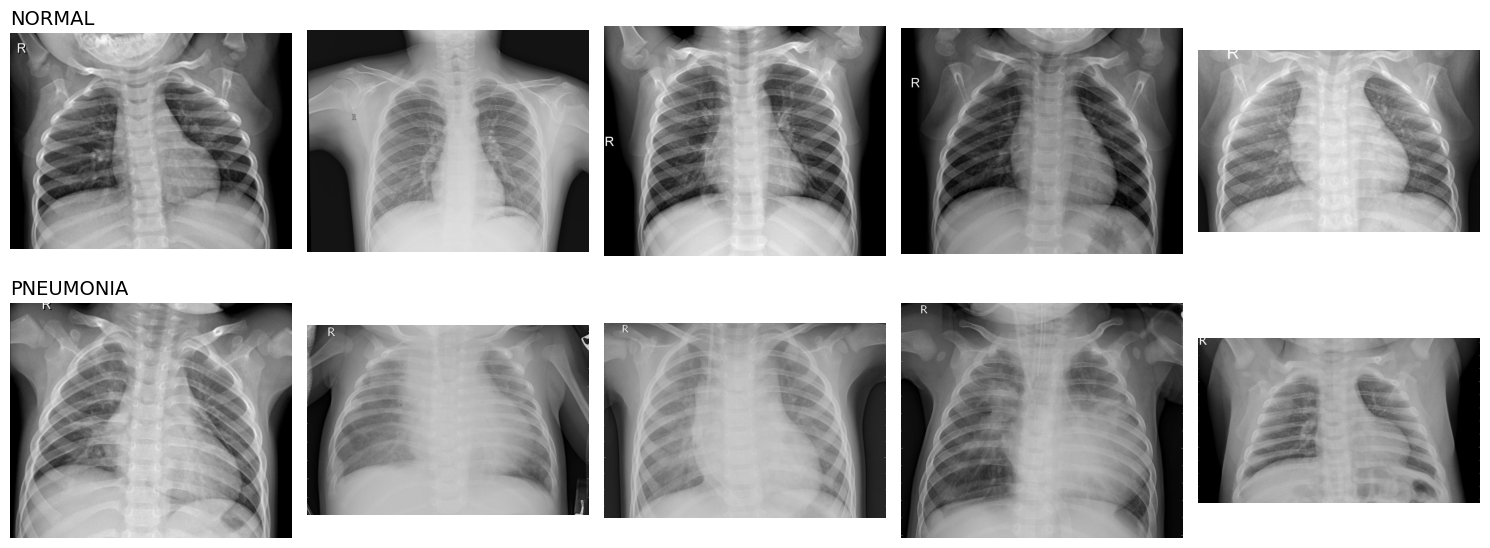

In [31]:
import os
import random
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

train_dir = Path(target_train_path)
classes = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
n_per_class = 5

fig, axes = plt.subplots(len(classes), n_per_class,
                         figsize=(n_per_class * 3, len(classes) * 3))

axes = np.atleast_2d(axes)

for row, cls in enumerate(classes):
    class_dir = train_dir / cls
    files = [f for f in class_dir.iterdir()
             if f.suffix.lower() in ('.png', '.jpg', '.jpeg')]
    files = random.sample(files, min(len(files), n_per_class))

    for col in range(n_per_class):
        ax = axes[row, col]
        ax.axis('off')

        if col < len(files):
            img = Image.open(files[col]).convert('RGB')
            ax.imshow(img)

        if col == 0:
            ax.set_title(cls, fontsize=14, loc='left')

plt.tight_layout()
plt.show()


-----

##  Justificación de la Estrategia de Balanceo y Data augmentantion

El *set* de entrenamiento presenta un **desbalance de clases significativo**, con una proporción de $2.9$ imágenes de **Pneumonía** por cada imagen de **Normal**. Dado el limitado número de imágenes, aplicaremos un **Pipeline Híbrido** para mitigar los riesgos de **sobreajuste** y **sesgo**.

---

### Estrategia de Mitigación

1.  **Data Augmentation Dinámico:**
    * **Finalidad:** Se aplica Aumento de Datos dinámico (*on-the-fly*) al *dataset* de entrenamiento. Esta técnica incrementa la **variedad** de la clase minoritaria (**Normal**), lo cual es crucial para prevenir el **sobreajuste** que podría ocurrir al contar con tan pocas imágenes originales en esa clase.

2.  **Ponderación de Clases:**
    * **Finalidad:** Se implementa Ponderación de Clases (*Class Weighting*) en la función de pérdida. Esta decisión es necesaria porque, a pesar de aplicar *Data Augmentation* a todo el *dataset*, el **sesgo de frecuencia** se mantiene en los *batches* de entrenamiento. La ponderación garantiza un aprendizaje más **equilibrado** al aumentar el peso de penalización por error en la clase **Normal**.

De esta manera, se ataca el desbalance desde el dominio de los datos (variedad) y desde el dominio algorítmico (importancia), sin la necesidad de reducir el tamaño del *dataset*.

### 1. Comenzamos el pipeline para el preprocesamiento de las imagenes

In [32]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Empezamos el pipeline definiendo los tamaños de imagen y el tamaño del batch
img_size = (180, 180)
batch = 32

In [33]:
train_path = target_train_path
test_path = target_test_path
val_path = target_val_path


In [34]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## Cargar datos:
Creamos un pipeline para que se pueda tomar las imagenes y cargar en batches

In [35]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    label_mode='binary',
    image_size=img_size,
    batch_size=batch,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    label_mode='binary',
    image_size=img_size,
    batch_size=batch,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    label_mode='binary',
    image_size=img_size,
    batch_size=batch,
    shuffle=False
)

class_names = train_ds.class_names
print("Clases detectadas:", class_names)


Found 4099 files belonging to 2 classes.
Found 877 files belonging to 2 classes.
Found 880 files belonging to 2 classes.
Clases detectadas: ['NORMAL', 'PNEUMONIA']


In [36]:
# Ponderación de clases para mitigar desbalance
train_counts = {}
for cls in class_names:
    cls_dir = os.path.join(train_path, cls)
    train_counts[cls] = len([
        f for f in os.listdir(cls_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]) if os.path.isdir(cls_dir) else 0

total = sum(train_counts.values())
class_weights = {}
for idx, cls in enumerate(class_names):
    count = train_counts.get(cls, 0)
    class_weights[idx] = total / (len(class_names) * count) if count > 0 else 1.0

print("Imágenes por clase (train):", train_counts)
print("Class weights:", class_weights)


Imágenes por clase (train): {'NORMAL': 1108, 'PNEUMONIA': 2991}
Class weights: {0: 1.8497292418772564, 1: 0.6852223336676697}


prefetch hace que mientras el modelo entrena con un batch, el siguiente ya se esté cargando.

In [37]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)


BLOQUE DE DATA AUGMENTANTION 

In [38]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2)
], name='data_augmentation')

In [39]:
l2 = keras.regularizers.l2(1e-4)

model = keras.Sequential([
    keras.Input(shape=(180, 180, 3)),

    # Data augmentation dentro del modelo
    data_augmentation,

    # Normalización
    layers.Rescaling(1./255),

    # CNN con regularización L2 y Dropout
    layers.Conv2D(32, 3, padding="same", activation="relu", kernel_regularizer=l2),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu", kernel_regularizer=l2),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128, 3, padding="same", activation="relu", kernel_regularizer=l2),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, padding="same", activation="relu", kernel_regularizer=l2),
    layers.MaxPooling2D(),
    layers.Dropout(0.30),

    layers.Flatten(),
    layers.Dense(256, activation="relu", kernel_regularizer=l2),
    layers.Dropout(0.40),
    layers.Dense(1, activation="sigmoid")
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     7,930,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,318,785 (31.73 MB)

 Trainable params: 8,318,785 (31.73 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
checkpoint_path = os.path.join(path, 'modelo_v2_mejor.keras')
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True),
]

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc'),
    ]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks,
    class_weight=class_weights
)


Epoch 1/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 52s 385ms/step - accuracy: 0.5804 - auc: 0.6443 - loss: 0.7339 - precision: 0.8051 - recall: 0.5607 - val_accuracy: 0.8483 - val_auc: 0.9022 - val_loss: 0.6806 - val_precision: 0.9304 - val_recall: 0.8562
Epoch 2/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 47s 364ms/step - accuracy: 0.7712 - auc: 0.8500 - loss: 0.5504 - precision: 0.9053 - recall: 0.7666 - val_accuracy: 0.8712 - val_auc: 0.9421 - val_loss: 0.4064 - val_precision: 0.9285 - val_recall: 0.8922
Epoch 3/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 47s 362ms/step - accuracy: 0.8212 - auc: 0.9057 - loss: 0.4498 - precision: 0.9312 - recall: 0.8151 - val_accuracy: 0.8997 - val_auc: 0.9627 - val_loss: 0.3418 - val_precision: 0.9678 - val_recall: 0.8922
Epoch 4/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 45s 343ms/step - accuracy: 0.8512 - auc: 0.9304 - loss: 0.3940 - precision: 0.9464 - recall: 0.8439 - val_accuracy: 0.9156 - val_auc: 0.9649 - val_loss: 0.2825 - val_precision: 0.9579 - val_recall: 0.9250
Epoch 5/25
129/129 ━

In [44]:
test_metrics = model.evaluate(test_ds, return_dict=True)
print("Métricas en test:")
for name, value in test_metrics.items():
    print(f"  {name}: {value:.4f}")


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.9489 - auc: 0.9877 - loss: 0.1817 - precision: 0.9516 - recall: 0.9798
Métricas en test:
  accuracy: 0.9489
  auc: 0.9877
  loss: 0.1817
  precision: 0.9516
  recall: 0.9798


Precision: 0.9516  Recall: 0.9798  F1: 0.9655
Classification report:
              precision    recall  f1-score   support

      NORMAL     0.9406    0.8655    0.9015       238
   PNEUMONIA     0.9516    0.9798    0.9655       642

    accuracy                         0.9489       880
   macro avg     0.9461    0.9226    0.9335       880
weighted avg     0.9486    0.9489    0.9482       880



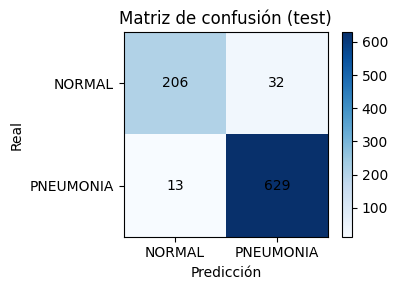

In [45]:
import numpy as np
import matplotlib.pyplot as plt
try:
    from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
except ImportError as e:
    raise ImportError('Se requiere scikit-learn para las métricas adicionales: pip install scikit-learn') from e

# Recoger probabilidades y etiquetas reales
y_true, y_prob = [], []
for batch_images, batch_labels in test_ds:
    y_true.extend(batch_labels.numpy().ravel())
    y_prob.extend(model.predict(batch_images, verbose=0).ravel())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

# Métricas
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
print(f"Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")

print("Classification report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(cm, cmap='Blues')
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
fig.colorbar(im, ax=ax)
plt.title('Matriz de confusión (test)')
plt.tight_layout()
plt.show()


## 2. Análisis del Modelo Versión 2

- **Mejoras aplicadas:** early stopping + checkpoint (val_loss), Dropout y L2, ponderación de clases, y métricas adicionales (precision, recall, F1, matriz de confusión).
- **Regularización:** la combinación de L2 y Dropout busca reducir sobreajuste y mejorar la generalización.
- **Clase minoritaria:** los `class_weights` elevan la penalización de errores en la clase con menos ejemplos, ayudando al equilibrio.
- **Evaluación:** metricas generadas.
- **Persistencia:** el mejor modelo se guarda en `modelo_v2_mejor.keras` para reutilizarlo en inferencia o servirlo vía API/streamlit.



### Confianza en la validacion
También es importante considerar que el **val_accuracy** no es completamente confiable en este contexto, debido al tamaño reducido del nuevo conjunto de validación (15% del dataset consolidado) y a la ausencia de técnicas como validación cruzada (cross-validation). Esto hace que las métricas de validación sean más inestables y sensibles al muestreo.

### Metricas de testing
A pesar de estas limitaciones, en la ejecución original se obtuvo un test_accuracy cercano a 0.77. Con la nueva partición 70/15/15 estos valores pueden cambio a 0.9489; el accuracy por sí solo no es una métrica adecuada en presencia de desbalance de clases y posibles sesgos en el entrenamiento.

afortunadabamente agregamos metricas mas completas, como el f1 donde podemos ver como mejoro el modelo


--------------------------------------------------------------------------

## Reporte resumido de la versión 2

- **Datos:** partición 70/15/15 consolidada; preprocesado con `image_dataset_from_directory` y `prefetch`.
- **Balanceo:** `class_weights` calculados sobre `train_70` para compensar la clase minoritaria.
- **Modelo:** CNN con data augmentation + L2 + Dropout; optimizador Adam lr=1e-4.
- **Entrenamiento:** early stopping y checkpoint en `modelo_v2_mejor.keras`; métricas de entrenamiento incluyen accuracy/precision/recall/AUC.
- **Evaluación:** métricas en test impresas (accuracy, loss, precision, recall, F1, AUC) y matriz de confusión.
- **Umbral:** decisión por defecto 0.5; si se requiere mayor sensibilidad, ajustar y recalcular métricas.

### Justificación con métricas 
- Mejor `val_loss` (fit principal): ~0.288  | epoch: 4 (early stopping)
- Test accuracy: 0.9489  | test loss: 0.1817
- Precision: 0.9516  | Recall: 0.9798  | F1: 0.9655  | AUC: 0.9877
- Observaciones: buen balance precisión/recall; recall alto para PNEUMONIA. Usa `modelo_v2_mejor.keras` para inferencia; si buscas más sensibilidad, baja el umbral (p. ej. 0.45) y recalcula métricas.
